# Results

A Bayesian workflow on a simple straight-line regression, taken from the
posterior the No-U-Turn sampler produces. We move through it in order:
1. the model and its priors;
2. what those priors imply before any data is seen;
3. then the fitted posterior of each parameter, and the posterior predictive shown
the same three ways as the prior: its density, sample draws and the spread it
implies.

This is the only notebook that runs the sampler. It saves the run and a few
derived quantities to `outputs/notebook_run`; the Diagnostics and Calibration
notebooks read that directory and never refit. The model is conjugate, so
every sampled quantity has a closed-form reference to check against.

## The model

Observe $n$ responses $y_i$ at scalar inputs $x_i$ and model them as a
straight line with Gaussian noise,

$$ y_i = \beta_0 + \beta_1 x_i + \varepsilon_i, \qquad
   \varepsilon_i \sim \mathcal{N}(0, \sigma^2). $$

I place a conjugate Normal-Inverse-Gamma prior on the coefficients $\beta$ and
the noise variance $\sigma^2$. Conjugacy ensure the posterior is available in closed form, which gives an exact reference to check the sampler against.
The sampler works in the unconstrained vector
$z = (\beta, \log\sigma)$ so the scale can move on the whole Real line.

In [1]:
import sys
from pathlib import Path

# The project root is the directory holding src/toynuts. From it we put the
# package on the path (no install needed) and fix one run directory the three
# notebooks share: Results writes it, Diagnostics and Calibration read it.
PROJECT_ROOT = next(
    (p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "toynuts").is_dir()),
    Path.cwd(),
)
if not any((Path(p) / "toynuts").is_dir() for p in sys.path):
    sys.path.insert(0, str(PROJECT_ROOT / "src"))
RUN_DIR = PROJECT_ROOT / "outputs" / "notebook_run"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sps
from scipy.special import polygamma

from toynuts.models.linear_gaussian import LinearGaussian
from toynuts.sampler import SamplerConfig, sample
from toynuts.io import to_dataframes, write_run
from toynuts.calibration import pit_rb, rank_statistic
from toynuts import plotting as P

plt.rcParams["figure.dpi"] = 110

# A simple linear regression: one input x, an intercept and Gaussian noise. The
# data seed is a representative draw, one where the posterior settles close to the
# generating values rather than an unlucky outlier.
data_rng = np.random.default_rng(131)
n = 80
x = np.sort(data_rng.uniform(-2.5, 2.5, n))
X = np.column_stack([np.ones(n), x])
beta_true = np.array([1.0, 2.0])          # intercept, slope
sigma_true = 1.0
y = X @ beta_true + sigma_true * data_rng.standard_normal(n)

# Conjugate Normal-Inverse-Gamma prior. V0 is deliberately wide so the prior is
# weakly informative; the posterior will turn out roughly ten times tighter.
m0 = np.zeros(2)
V0 = np.diag([2.0, 2.0])
a0, b0 = 6.0, 5.0
model = LinearGaussian(X, y, m0, V0, a0, b0)


def matched_metric(mdl):
    """Fixed diagonal metric from the analytic posterior variances.

    The beta block uses the marginal posterior variances; the scale uses
    Var[log sigma] = 0.25 * trigamma(a_n). Nothing here is adapted during sampling.
    """
    mom = mdl.analytic_posterior_moments()
    var_z = np.concatenate([np.diag(mom["beta_cov"]), [0.25 * polygamma(1, mdl.a_n)]])
    return np.diag(1.0 / var_z)

print(f"observations n = {model.n}, coefficients p = {model.p}, dim z = {model.dim}")
print("parameters:", model.param_names)

observations n = 80, coefficients p = 2, dim z = 3
parameters: ['beta_0', 'beta_1', 'sigma']


## The priors of each parameter

Before fitting, the prior says what we believe about each parameter. The
histograms are a large i.i.d. draw from the prior; the solid curves are the
analytic marginals (a Student-t for each coefficient, the transformed
Inverse-Gamma for the scale). The dashed line marks the value that generated
the data, well inside the prior in every case. The final panel repeats the
scale as $u = \log\sigma$, the space the sampler actually works in.

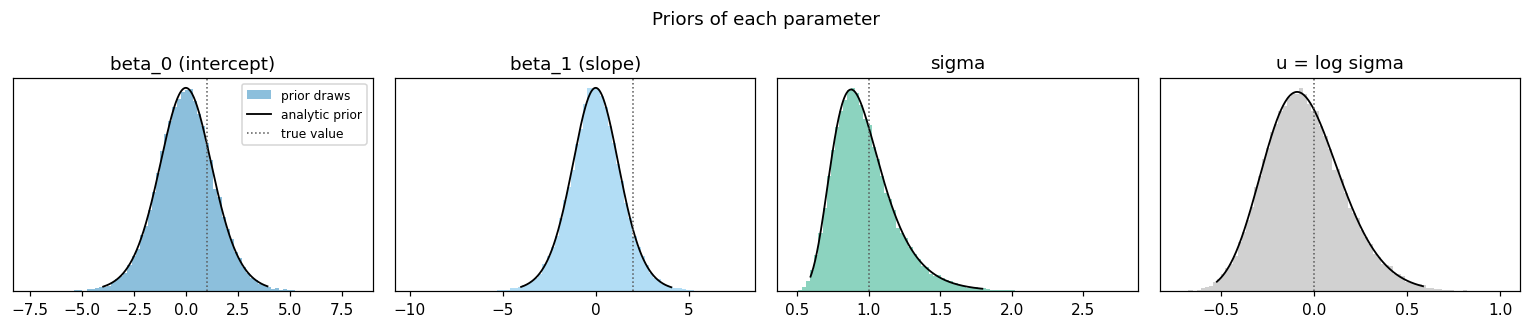

In [2]:
prior = model.prior_draws(40000, np.random.default_rng(10))
# Append u = log sigma, the scale in the space the sampler works in.
prior = np.column_stack([prior, np.log(prior[:, 2])])
names = ["beta_0 (intercept)", "beta_1 (slope)", "sigma", "u = log sigma"]
truth = [beta_true[0], beta_true[1], sigma_true, np.log(sigma_true)]

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for k, ax in enumerate(axes):
    colour = P.param_colour(k)
    ax.hist(prior[:, k], bins=80, density=True, alpha=0.45, color=colour, label="prior draws")
    grid = np.linspace(*np.quantile(prior[:, k], [0.005, 0.995]), 300)
    if k < 2:
        scale = np.sqrt((b0 / a0) * V0[k, k])
        pdf = sps.t(df=2 * a0, loc=m0[k], scale=scale).pdf(grid)
    elif k == 2:
        # sigma = sqrt(sigma**2) with sigma**2 ~ IG, so multiply by the Jacobian 2 sigma.
        pdf = sps.invgamma(a=a0, scale=b0).pdf(grid**2) * 2 * grid
    else:
        # u = 0.5 log sigma**2, whose density carries the Jacobian 2 exp(2u).
        pdf = sps.invgamma(a=a0, scale=b0).pdf(np.exp(2 * grid)) * 2 * np.exp(2 * grid)
    ax.plot(grid, pdf, "k", lw=1.2, label="analytic prior")
    ax.axvline(truth[k], color="#555555", ls=":", lw=1, label="true value")
    ax.set_title(names[k])
    ax.set_yticks([])
axes[0].legend(fontsize=8)
fig.suptitle("Priors of each parameter")
fig.tight_layout()
plt.show()

## Prior pushforward: what the priors imply together

Per-parameter plausibility does not imply joint plausibility. Pushing the prior
forward onto data-scale quantities, the mean response at the extremes of $x$, the
slope effect across the observed range and the residual scale against the spread
of $y$, is where priors that look benign one at a time reveal themselves.

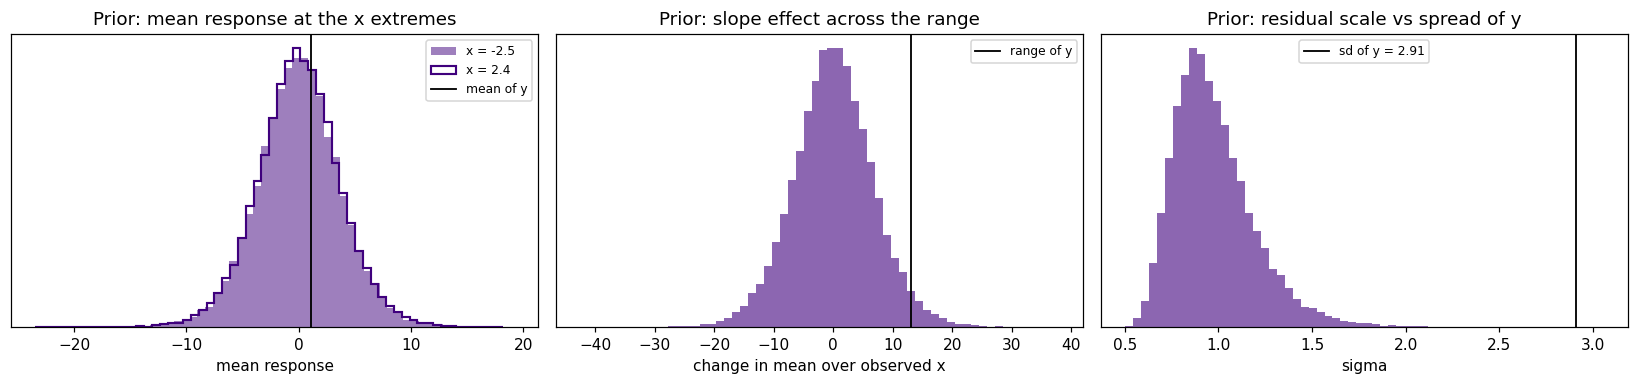

In [3]:
def pushforward_panels(draws, kind):
    """Push prior or posterior draws forward onto data-scale quantities."""
    beta, sigma = draws[:, :2], draws[:, 2]
    x_lo, x_hi = x.min(), x.max()
    mean_lo = beta[:, 0] + beta[:, 1] * x_lo
    mean_hi = beta[:, 0] + beta[:, 1] * x_hi
    slope_effect = beta[:, 1] * (x_hi - x_lo)
    colour = P.role_colour(kind)

    fig, (a, b, c) = plt.subplots(1, 3, figsize=(15, 3.6))
    a.hist(mean_lo, bins=60, density=True, alpha=0.5, color=colour, label=f"x = {x_lo:.1f}")
    a.hist(mean_hi, bins=60, density=True, histtype="step", lw=1.4, color=colour, label=f"x = {x_hi:.1f}")
    a.axvline(y.mean(), color=P.DATA_COLOUR, lw=1.2, label="mean of y")
    a.set(title=f"{kind}: mean response at the x extremes", xlabel="mean response", yticks=[])
    a.legend(fontsize=8)
    b.hist(slope_effect, bins=60, density=True, alpha=0.6, color=colour)
    b.axvline(np.ptp(y), color=P.DATA_COLOUR, lw=1.2, label="range of y")
    b.set(title=f"{kind}: slope effect across the range", xlabel="change in mean over observed x", yticks=[])
    b.legend(fontsize=8)
    c.hist(sigma, bins=60, density=True, alpha=0.6, color=colour)
    c.axvline(y.std(), color=P.DATA_COLOUR, lw=1.2, label=f"sd of y = {y.std():.2f}")
    c.set(title=f"{kind}: residual scale vs spread of y", xlabel="sigma", yticks=[])
    c.legend(fontsize=8)
    fig.tight_layout()
    plt.show()


pushforward_panels(model.prior_draws(40000, np.random.default_rng(21)), "Prior")

## Prior predictive: what the priors imply for the line

Three views of the same prior predictive. The density is the Rao-Blackwellised
predictive $\frac{1}{S}\sum_s p(\tilde y \mid \tilde x, \theta_s)$, the Gaussian
likelihood averaged over the prior draws: this integrates the observation noise
out per draw, and its central 95% interval is found by inverting the same mixture,
so nothing about $\tilde y$ is sampled. The sample lines push prior draws of
$(\beta, \sigma)$ through the model directly. The spread panel integrates the
noise out too, showing the population standard deviation each draw implies against
the observed one. All three spread widely and pay no attention to the data, which
is what a weakly informative prior should look like.

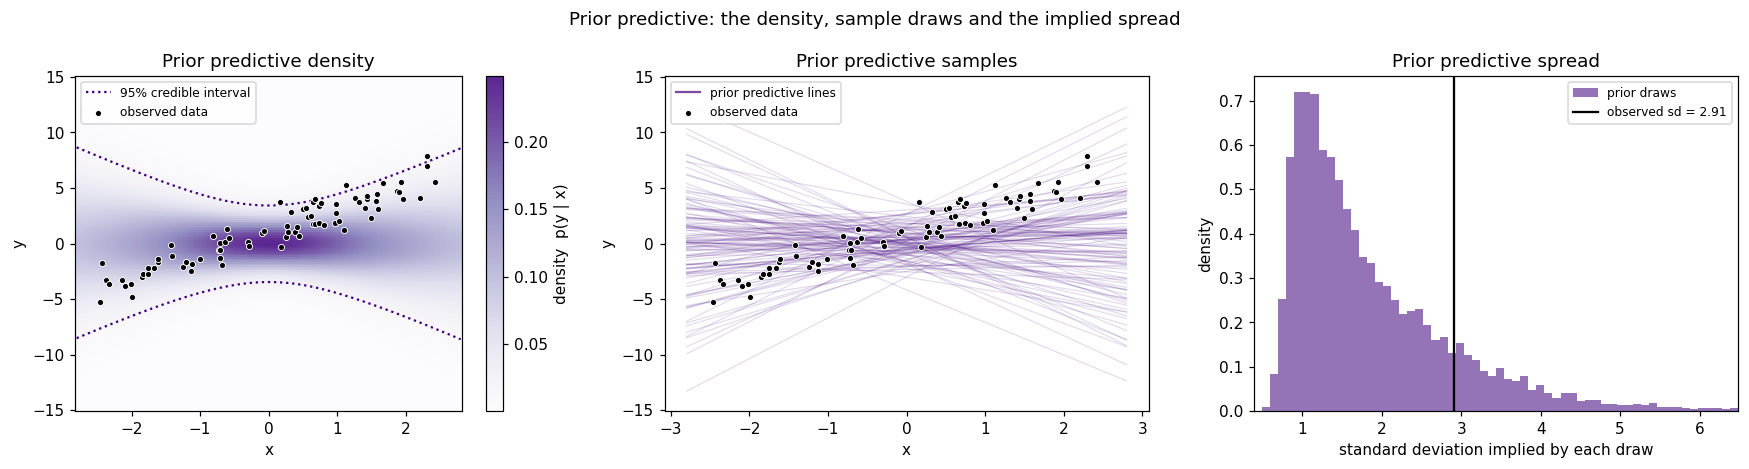

In [4]:
import matplotlib.patheffects as pe

CASING = [pe.Stroke(linewidth=2.6, foreground="white"), pe.Normal()]


def predictive_panels(draws, line_draws, kind):
    """Three predictive views from prior or posterior draws of (beta, sigma).

    The density is the Rao-Blackwellised predictive,
    mean_s N(y; x @ beta_s, sigma_s**2): the observation noise is integrated out
    per draw (the Gaussian density, never a sampled y) and the parameter
    uncertainty is averaged over the draws. Its 95% interval inverts the same
    mixture CDF, so nothing about y is sampled. The spread integrates the noise out
    too, the population sd each draw implies. The ribbon is cool for the prior and
    warm for the posterior. Only the centre panel shows draws.
    """
    grid_x = np.linspace(-2.8, 2.8, 120)
    grid_X = np.column_stack([np.ones_like(grid_x), grid_x])

    beta, sigma = draws[:, :2], draws[:, 2]
    means = beta @ grid_X.T

    # Rao-Blackwellised density and its 95% interval, one x-column at a time. The
    # window spans 3.5 total sds, the mixture's law-of-total-variance spread.
    mu = means.mean(0)
    total_sd = np.sqrt((means**2 + (sigma**2)[:, None]).mean(0) - mu**2)
    y_grid = np.linspace((mu - 3.5 * total_sd).min(), (mu + 3.5 * total_sd).max(), 200)
    pdf_norm = 1.0 / (sigma * np.sqrt(2.0 * np.pi))
    dens = np.empty((y_grid.size, grid_x.size))
    lo, hi = np.empty(grid_x.size), np.empty(grid_x.size)
    for j in range(grid_x.size):
        z = (y_grid[:, None] - means[:, j][None, :]) / sigma[None, :]
        dens[:, j] = (np.exp(-0.5 * z**2) * pdf_norm[None, :]).mean(axis=1)
        cdf = sps.norm.cdf(z).mean(axis=1)
        lo[j], hi[j] = np.interp([0.025, 0.975], cdf, y_grid)
    ylim = (y_grid.min(), y_grid.max())

    pp_lines = model.predictive_draws(line_draws, grid_X)
    # Population sd implied by each draw, noise integrated out.
    implied_sd = np.sqrt((beta @ model.X.T).var(axis=1) + sigma**2)
    obs_sd = float(y.std())
    sd_lo = min(float(np.quantile(implied_sd, 0.005)), obs_sd)
    sd_hi = max(float(np.quantile(implied_sd, 0.995)), obs_sd)
    pad = 0.05 * (sd_hi - sd_lo)
    sd_range = (max(0.0, sd_lo - pad), sd_hi + pad)

    cmap, deep = P.cmap_for(kind), P.deep_for(kind)
    fig, (ax_l, ax_c, ax_r) = plt.subplots(1, 3, figsize=(16, 4.3))

    mesh = ax_l.pcolormesh(grid_x, y_grid, dens, cmap=cmap, shading="auto", alpha=P.RIBBON_ALPHA)
    fig.colorbar(mesh, ax=ax_l, label="density  p(y | x)")
    for edge in (lo, hi):
        ax_l.plot(grid_x, edge, color=deep, lw=1.5, ls=P.CI_LINE_STYLE, path_effects=CASING)
    ax_l.plot([], [], color=deep, lw=1.5, ls=P.CI_LINE_STYLE, label="95% credible interval")
    P.scatter_data(ax_l, x, y)
    ax_l.set(xlabel="x", ylabel="y", title=f"{kind} predictive density", ylim=ylim)
    ax_l.legend(loc="upper left", fontsize=8)

    ax_c.plot(grid_x, pp_lines.T, color=deep, alpha=0.14, lw=0.8)
    ax_c.plot([], [], color=deep, alpha=0.7, label=f"{kind.lower()} predictive lines")
    P.scatter_data(ax_c, x, y)
    ax_c.set(xlabel="x", ylabel="y", title=f"{kind} predictive samples", ylim=ylim)
    ax_c.legend(loc="upper left", fontsize=8)

    ax_r.hist(implied_sd, bins=60, range=sd_range, density=True, color=deep, alpha=0.55,
              label=f"{kind.lower()} draws")
    ax_r.axvline(obs_sd, color=P.DATA_COLOUR, lw=1.5, label=f"observed sd = {obs_sd:.2f}")
    ax_r.set(xlabel="standard deviation implied by each draw", ylabel="density",
             title=f"{kind} predictive spread", xlim=sd_range)
    ax_r.legend(loc="upper right", fontsize=8)

    fig.suptitle(f"{kind} predictive: the density, sample draws and the implied spread")
    fig.tight_layout()
    plt.show()


prior_rng = np.random.default_rng(11)
predictive_panels(model.prior_draws(8000, prior_rng), model.prior_draws(120, prior_rng), "Prior")

## Prior-data conflict

Where does the observed data fall within the prior predictive? Each point's
prior-predictive CDF value (Rao-Blackwellised over prior draws) is uniform when
the prior predictive is consistent with the data; mass piling at 0 or 1 would
flag the data sitting in the prior's tails, a conflict to resolve before
fitting.

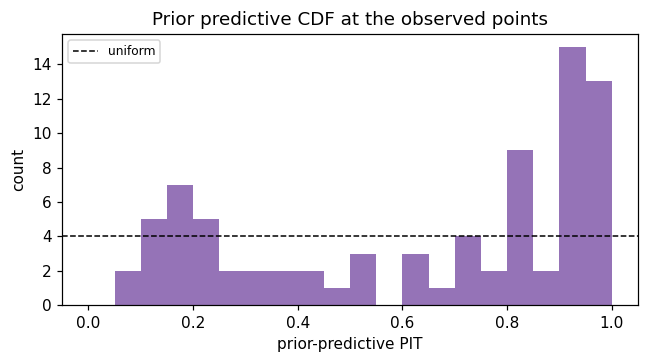

fraction of points in the prior-predictive tails: 0.000 (0 means no prior-data conflict)


In [5]:
prior_for_pit = model.prior_draws(8000, np.random.default_rng(22))
prior_pit = pit_rb(y, X, prior_for_pit)
extreme = np.mean((prior_pit < 0.005) | (prior_pit > 0.995))

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.hist(prior_pit, bins=20, range=(0, 1), color=P.role_colour("Prior"), alpha=0.55)
ax.axhline(len(y) / 20, color="k", ls="--", lw=1, label="uniform")
ax.set(title="Prior predictive CDF at the observed points",
       xlabel="prior-predictive PIT", ylabel="count")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()
print(f"fraction of points in the prior-predictive tails: {extreme:.3f} "
      f"(0 means no prior-data conflict)")

## Fitting the posterior

I run four chains of NUTS with a fixed step size and a metric matched to the
analytic posterior scales, then save the run straight away so the Diagnostics
notebook can read it. The run is checked in full there; here we only confirm
it is clean and keep the draws.

In [6]:
config = SamplerConfig(n_chains=4, n_draws=2000, step_size=0.3, metric=matched_metric(model), seed=2)
run = sample(model, config)
draws, stats, run_config = to_dataframes(run, config, model)
post = draws[["beta_0", "beta_1", "sigma"]].to_numpy()

RUN_DIR.mkdir(parents=True, exist_ok=True)
write_run(RUN_DIR, draws, stats, run_config)
print("saved run to", RUN_DIR)
print("posterior draws:", post.shape[0], " divergences:", int(stats["divergent"].sum()))

saved run to /home/s95717/data_science_public/toy-nuts-bayes/outputs/notebook_run
posterior draws: 8000  divergences: 0


## The posterior of each parameter

The sampled marginals (filled) sit on top of exact i.i.d. draws from the
closed-form posterior (outline). They agree, and both have collapsed from the
wide prior of a moment ago onto a tight band around the true values. The
posterior mean lands near each true value but not exactly on it: with finite
data the centre is the truth plus a little noise, and the width is how much
that centre could still be off. The final panel shows the same recovery for
$u = \log\sigma$, the scale in the sampler's space, more symmetric than the
$\sigma$ it came from.

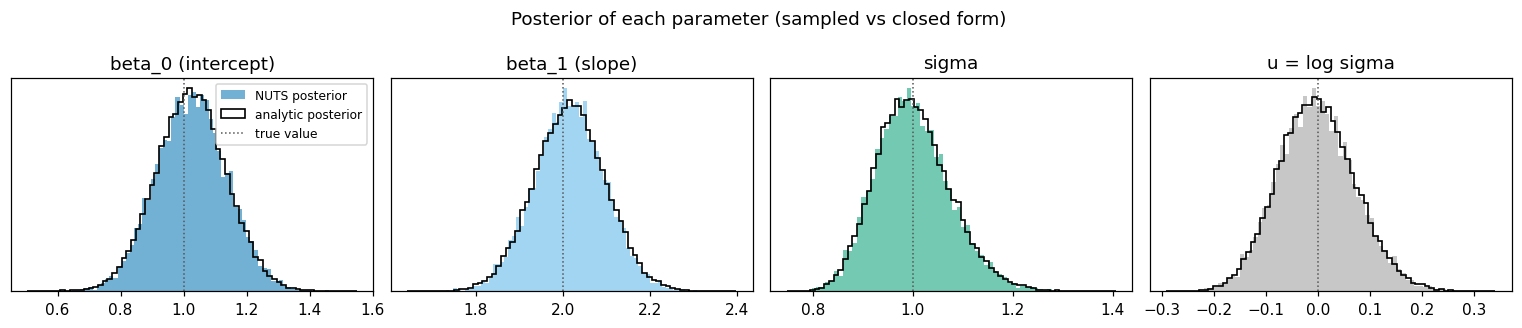

In [7]:
ref = model.analytic_posterior_draws(40000, np.random.default_rng(12))
# Append u = log sigma to the sampled and the reference draws.
post_u = np.column_stack([post, np.log(post[:, 2])])
ref_u = np.column_stack([ref, np.log(ref[:, 2])])

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for k, ax in enumerate(axes):
    colour = P.param_colour(k)
    ax.hist(post_u[:, k], bins=70, density=True, alpha=0.55, color=colour, label="NUTS posterior")
    ax.hist(ref_u[:, k], bins=70, density=True, histtype="step", color="k", lw=1.1,
            label="analytic posterior")
    ax.axvline(truth[k], color="#555555", ls=":", lw=1, label="true value")
    ax.set_title(names[k])
    ax.set_yticks([])
axes[0].legend(fontsize=8)
fig.suptitle("Posterior of each parameter (sampled vs closed form)")
fig.tight_layout()
plt.show()

## Prior against posterior: the contraction

The same colour per parameter, the prior dashed and faded, the posterior solid
and full, so the collapse from the wide prior onto the tight posterior reads at a
glance and even in greyscale.

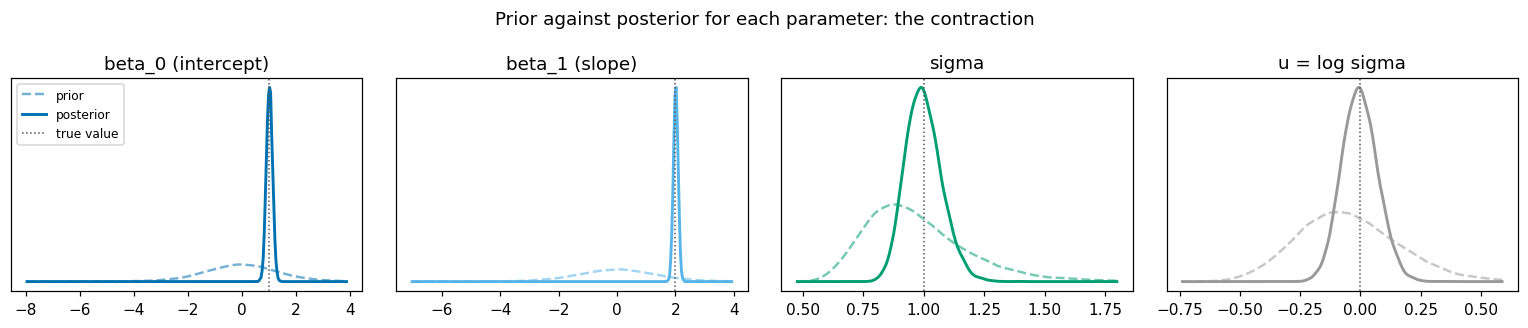

In [8]:
from scipy.stats import gaussian_kde

prior_o = model.prior_draws(40000, np.random.default_rng(23))
prior_o = np.column_stack([prior_o, np.log(prior_o[:, 2])])
post_o = np.column_stack([post, np.log(post[:, 2])])

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for k, ax in enumerate(axes):
    colour = P.param_colour(k)
    grid = np.linspace(min(prior_o[:, k].min(), post_o[:, k].min()),
                       np.quantile(prior_o[:, k], 0.995), 300)
    ax.plot(grid, gaussian_kde(prior_o[:, k])(grid), color=colour, label="prior", **P.PRIOR_STYLE)
    ax.plot(grid, gaussian_kde(post_o[:, k])(grid), color=colour, label="posterior",
            **P.POSTERIOR_STYLE)
    ax.axvline(truth[k], color="#555555", ls=":", lw=1, label="true value")
    ax.set_title(names[k])
    ax.set_yticks([])
axes[0].legend(fontsize=8)
fig.suptitle("Prior against posterior for each parameter: the contraction")
fig.tight_layout()
plt.show()

## Posterior pushforward

The same data-scale views as the prior pushforward, now from the posterior draws,
to confirm the fitted model is sensible on the data scale.

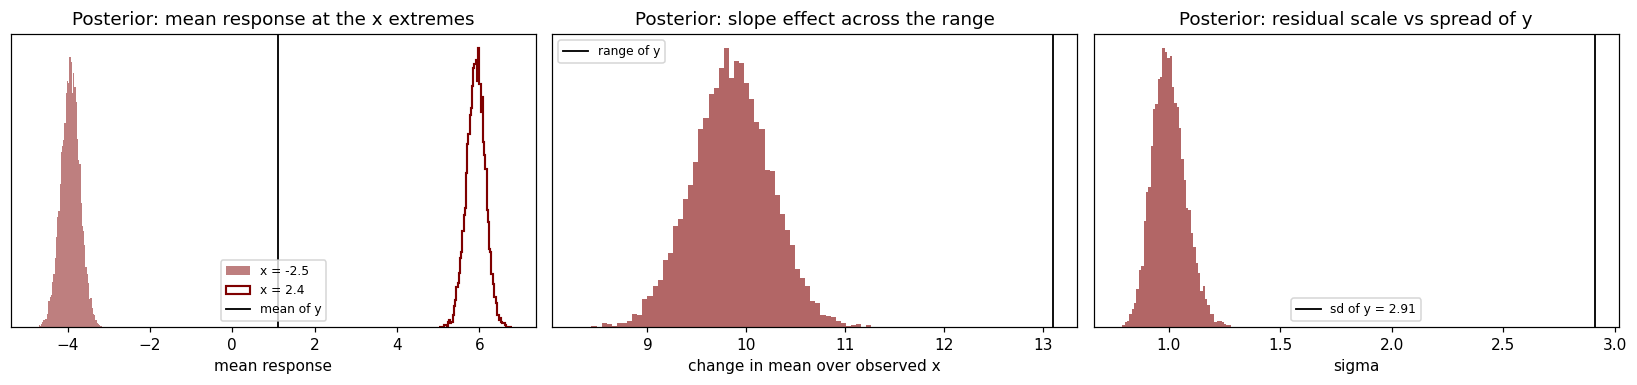

In [9]:
pushforward_panels(post, "Posterior")

## A quantitative check against the closed form

The overlay above is convincing by eye - here it is in numbers.

For each parameter we compare the sampled posterior mean and standard deviation against
the exact Normal-Inverse-Gamma values (for $\sigma$ these come from the moments
of the square root of an Inverse-Gamma). The yardstick for the mean is the Monte
Carlo standard error: the column $z$ is the discrepancy in MCSE units, so values
within a few are sampling noise rather than bias. The spread is read off the
ratio of sampled to analytic standard deviation, which should sit at one.

In [10]:
from scipy.special import gammaln

from toynuts.diagnostics import mcse_mean

mom = model.analytic_posterior_moments()
mcse = mcse_mean(draws)

# Analytic posterior mean and sd of each stored parameter. The beta moments are
# read straight off the closed form; for sigma we use the moments of the square
# root of an Inverse-Gamma, E[sigma**k] = b_n**(k/2) * Gamma(a_n - k/2) / Gamma(a_n),
# which give the mean and, with E[sigma**2] = b_n / (a_n - 1), the variance.
a_n, b_n = model.a_n, model.b_n
sigma_mean = np.sqrt(b_n) * np.exp(gammaln(a_n - 0.5) - gammaln(a_n))
sigma_sd = np.sqrt(b_n / (a_n - 1.0) - sigma_mean**2)
analytic_mean = np.array([mom["beta_mean"][0], mom["beta_mean"][1], sigma_mean])
analytic_sd = np.array([np.sqrt(mom["beta_cov"][0, 0]), np.sqrt(mom["beta_cov"][1, 1]), sigma_sd])

names = ["beta_0", "beta_1", "sigma"]
sampled_mean = post.mean(0)
sampled_sd = post.std(0, ddof=1)
mcse_vec = mcse[names].to_numpy()

check = pd.DataFrame(
    {
        "analytic mean": analytic_mean,
        "sampled mean": sampled_mean,
        "mcse": mcse_vec,
        "z": (sampled_mean - analytic_mean) / mcse_vec,
        "analytic sd": analytic_sd,
        "sampled sd": sampled_sd,
        "sd ratio": sampled_sd / analytic_sd,
    },
    index=names,
)
print(f"largest mean error {np.abs(check['z']).max():.2f} MCSE, "
      f"sd ratios in [{check['sd ratio'].min():.3f}, {check['sd ratio'].max():.3f}]")
check.round(4)

largest mean error 0.71 MCSE, sd ratios in [0.978, 1.010]


,analytic mean,sampled mean,mcse,z,analytic sd,sampled sd,sd ratio
beta_0,1.0240,1.0251,0.0016,0.7050,0.1119,0.1130,1.0098
beta_1,2.0160,2.0153,0.0010,-0.6530,0.0827,0.0809,0.9779
sigma,1.0006,1.0003,0.0010,-0.2599,0.0747,0.0748,1.0018


## Posterior predictive: what the data implies

The same three views, now averaged over the sampler's own posterior draws. The
density has collapsed onto a tight band along the data, the sample lines barely
fan out and the implied standard deviation concentrates on the observed value.

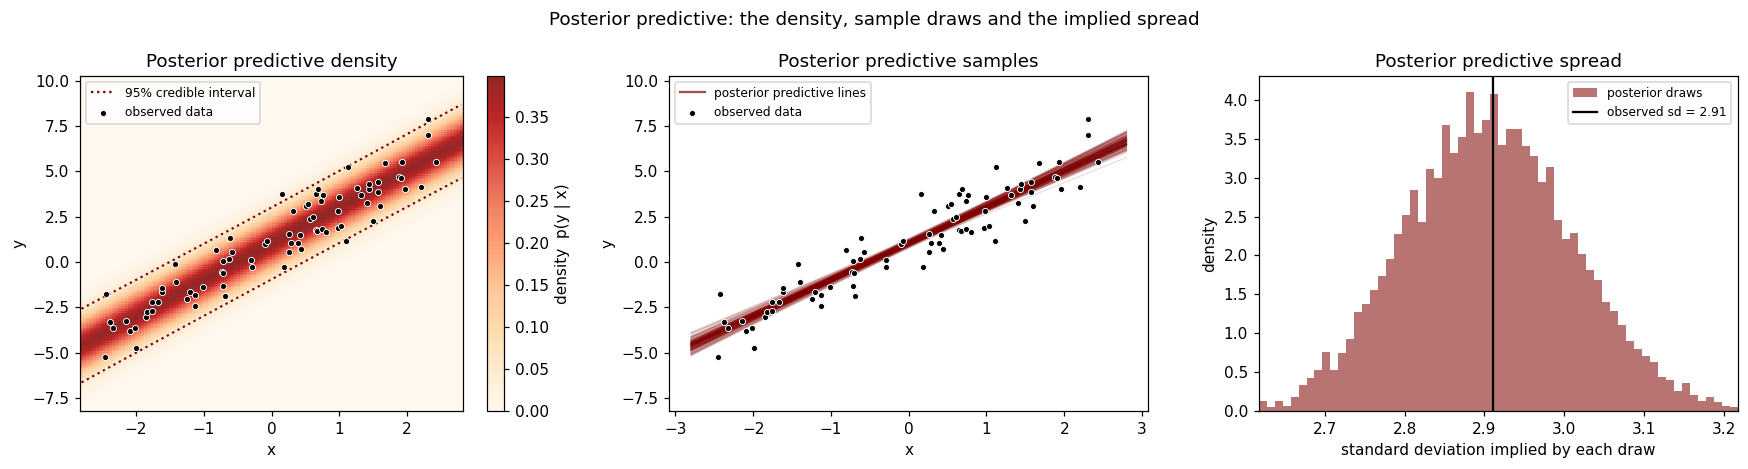

In [11]:
idx = np.random.default_rng(13).choice(post.shape[0], 150, replace=False)
predictive_panels(post, post[idx], "Posterior")

## Saving the inputs for the Calibration notebook

Three things are written for the Calibration notebook. The training set and a
held-out test set from the same process, and the simulation-based calibration
ranks: many small datasets drawn from the prior, refitted, with the rank of each
true value recorded. The Calibration notebook computes the predictive checks
itself from the saved posterior draws, so no sampled predictive replicates are
stored. The SBC loop is the slow step.

In [12]:
# Held-out test set from the same process. The Calibration notebook computes the
# predictive checks (PIT, LOO-PIT, coverage, scores) itself from the saved
# posterior draws, so only the training and test inputs are stored, not sampled
# predictive replicates.
test_rng = np.random.default_rng(50)
n_test = 400
x_test = test_rng.uniform(-2.5, 2.5, n_test)
X_test = np.column_stack([np.ones(n_test), x_test])
y_test = X_test @ beta_true + sigma_true * test_rng.standard_normal(n_test)
pd.DataFrame({"x": x, "y": y}).to_parquet(RUN_DIR / "train_set.parquet")
pd.DataFrame({"x_test": x_test, "y_test": y_test}).to_parquet(RUN_DIR / "test_set.parquet")

# Simulation-based calibration: prior draw -> simulate -> refit -> rank the truth.
n_sims, sbc_draws, thin = 400, 300, 3
prior_rng = np.random.default_rng(100)
sim_rng = np.random.default_rng(200)
ranks = np.empty((n_sims, 3), dtype=int)
for i in range(n_sims):
    theta = model.prior_draws(1, prior_rng)[0]                  # true (beta_0, beta_1, sigma)
    y_sim = X @ theta[:2] + theta[2] * sim_rng.standard_normal(n)
    sim_model = LinearGaussian(X, y_sim, m0, V0, a0, b0)
    sc = SamplerConfig(n_chains=1, n_draws=sbc_draws, step_size=0.3,
                       metric=matched_metric(sim_model), seed=i, n_burnin=400)
    r = sample(sim_model, sc)
    # Constrained draws (beta_0, beta_1, sigma), thinned towards independence.
    drawn = np.column_stack([r.positions[0, :, :2], np.exp(r.positions[0, :, 2])])[::thin]
    ranks[i] = rank_statistic(theta[None, :], drawn[None, :, :])[0]
L = drawn.shape[0]
pd.DataFrame(ranks, columns=["beta_0", "beta_1", "sigma"]).to_parquet(RUN_DIR / "sbc_ranks.parquet")
pd.DataFrame([{"n_sims": n_sims, "n_thinned": L}]).to_parquet(RUN_DIR / "sbc_meta.parquet")
print("wrote:", sorted(p.name for p in RUN_DIR.glob("*.parquet")))

wrote: ['draws.parquet', 'run_config.parquet', 'sample_stats.parquet', 'sbc_meta.parquet', 'sbc_ranks.parquet', 'test_set.parquet', 'train_set.parquet']


## Where next

The posterior recovers the generating line and quantifies how sure it is
about it. Two questions remain, one per companion notebook: did the sampler
actually converge (Diagnostics) and is the uncertainty it reports honest
(Calibration). Both read the run saved here.